In [36]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")

In [37]:
path = './skill_builder_data_corrected_collapsed.csv'
data = pd.read_csv(path, encoding="latin1")

/tmp/ipykernel_2842803/1591248315.py:2: DtypeWarning: Columns (0: skill_id, 1: skill_name) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path, encoding="latin1")


In [38]:
df = data[["user_id", "problem_id", "skill_id", "correct", "order_id"]]
df = df.dropna(subset=["skill_id"]) # remove rows with no concept

In [39]:
df["skill_id"] = df["skill_id"].astype(int)
df["correct"] = df["correct"].astype(int)

In [40]:
df = df.sort_values(["user_id", "order_id"])

In [41]:
q_map = {q:i for i,q in enumerate(df["problem_id"].unique())}
c_map = {c:i for i,c in enumerate(df["skill_id"].unique())}

df["q"] = df["problem_id"].map(q_map)
df["c"] = df["skill_id"].map(c_map)
df["r"] = df["correct"]

In [ ]:
# First split: train + temp (test)
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

groups = df["user_id"].values
X = df.index.values
y = df["correct"].values

train_idx, test_idx = next(gss1.split(X, y, groups=groups))

df_train_full = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

# Second split: train / validation (from train_full)
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1,  # 10% of train_full -> validation
    random_state=42
)

groups_train = df_train_full["user_id"].values
X_train = df_train_full.index.values
y_train = df_train_full["correct"].values

train_idx2, val_idx = next(gss2.split(X_train, y_train, groups=groups_train))

df_train = df_train_full.iloc[train_idx2].copy()
df_val = df_train_full.iloc[val_idx].copy()

In [43]:
nb_question = len(q_map)
nb_concept = len(c_map)
print(nb_question, nb_concept)

17751 149


In [44]:
def build_student_seqs(d):
    seqs = []
    for uid, u_df in d.groupby("user_id"):
        q = u_df["q"].values
        c = u_df["c"].values
        r = u_df["r"].values
        if len(q) >= 2:   # need history + target
            seqs.append((q, c, r))
    return seqs

In [45]:
train_student_seqs = build_student_seqs(df_train)
test_student_seqs  = build_student_seqs(df_test)
val_student_seqs = build_student_seqs(df_val)

In [46]:
print("train users:", df_train["user_id"].nunique())
print("test users:", df_test["user_id"].nunique())

train users: 2997
test users: 833


In [47]:
context_size = 200  # matching official AKT seqlen

In [48]:
def build_samples(student_seqs):
    """Chunk long sequences and zero-pad short ones to context_size,
    matching the official AKT preprocessing (load_data.py)."""
    samples = []
    for q, c, r in student_seqs:
        L = len(q)
        n_split = 1
        if L > context_size:
            n_split = math.ceil(L / context_size)

        for k in range(n_split):
            start = k * context_size
            end = L if k == n_split - 1 else (k + 1) * context_size

            q_chunk = q[start:end]
            c_chunk = c[start:end]
            r_chunk = r[start:end]

            actual_len = len(q_chunk)
            if actual_len < 2:
                continue

            q_padded = np.zeros(context_size, dtype=np.int64)
            c_padded = np.zeros(context_size, dtype=np.int64)
            r_padded = np.zeros(context_size, dtype=np.int64)

            q_padded[:actual_len] = q_chunk
            c_padded[:actual_len] = c_chunk
            r_padded[:actual_len] = r_chunk

            samples.append((q_padded, c_padded, r_padded, actual_len))
    return samples


In [49]:
train_samples = build_samples(train_student_seqs)
test_samples  = build_samples(test_student_seqs)
val_samples = build_samples(val_student_seqs)

In [50]:
print(len(train_samples), len(test_samples), len(val_samples))

3320 929 386


In [51]:
# Embedding dimension
embedding_dim = 32
# Nb of attention heads
nb_head = 8

# Attentive Knowledge Tracing

In [52]:
class Head(nn.Module):
    def __init__(self, D = embedding_dim, head_size = embedding_dim//8, T = context_size, monotonic = False):
        super().__init__()

        # embedding dim
        self.D = D

        # monotonic attention head or simple attention head
        self.monotonic = monotonic

        # decay parameter
        if monotonic:
            self.theta_raw = nn.Parameter(torch.tensor(-2.0, dtype=torch.float32))

        # Dk = Dq = Dv
        self.head_size = head_size

        self.query_key = nn.Linear(D, head_size, bias=False)
        self.value = nn.Linear(D, head_size, bias=False)

        self.register_buffer('tril', torch.tril(torch.ones(T, T)))

    def forward(self, q_in, k_in, v_in):
        # x is of size B, T, D
        B, Tq, D = q_in.shape #Tq = Tk = T-1
        Tk = k_in.size(1)
        assert v_in.size(1) == Tk


        k = self.query_key(k_in) #  B, Tk, head_size
        q = self.query_key(q_in) #  B, Tq, head_size
        v = self.value(v_in) # B, Tk, head_size

        # (B, Tq, head_size) @ (B, head_size, Tq) = (B, Tq, Tq)
        weights = q @ k.transpose(-2, -1) * self.head_size**(-0.5)


        mask = self.tril[:Tq, :Tk]

        if self.monotonic:
            # COMPUTE d(t, tau)
            with torch.no_grad():

                scores_masked = weights.masked_fill(mask == 0, -1e32)
                gamma = F.softmax(scores_masked, dim = -1)
                gamma = gamma * mask.float()

                prefix = torch.cumsum(gamma, dim = -1)  # (B,Tq,Tk)

                temp = torch.arange(Tq, device=q_in.device)

                # prefix_at_t = prefix[b,t,t]
                prefix_at_t = prefix[:, temp, temp].unsqueeze(-1)  # (B,Tq,1)
                sum_tau1_to_t = prefix_at_t - prefix  # (B,Tq,Tq)

                abs_dtau = (temp.view(1, Tq, 1) - temp.view(1, 1, Tq)).abs().float()  # (1,Tq,Tq)
                d = torch.clamp(abs_dtau * sum_tau1_to_t, min = 0.) # (B, Tq, Tk), clamp to be non-negative

                d = d.sqrt().detach()

            decay_rate = F.softplus(self.theta_raw)
            # Clamp for numerical stability
            decay_rate = torch.clamp(decay_rate, max=10.0)

            # Compute final weights
            factor = torch.clamp(torch.clamp((-d*decay_rate).exp(), min = 1e-5), max = 1e5) # of size (B,Tq, Tq)
            weights = weights * factor # of size (B,Tq, Tq)

        # Apply mask after monotonic attention
        weights = weights.masked_fill(mask == 0, float('-inf'))
        weights = F.softmax(weights, dim = -1)

        # (B, T, T) @ (B, T, head_size) = (B, T, head_size)
        out = weights @ v

        return out # (B, T, head_size)

In [53]:
class Multi(nn.Module):
    def __init__(self, nb_head, monotonic, D = embedding_dim, head_size = embedding_dim//8, T = context_size, dropout = 0.2):
        super().__init__()
        self.nb_head = nb_head
        self.head_size = head_size

        # selfcount = False if monotonic True otherwise
        self.heads = nn.ModuleList([Head(D, head_size, T, monotonic) for _ in range(nb_head)])

        self.proj = nn.Linear(nb_head * head_size, D)
        self.drop = nn.Dropout(dropout)


    def forward(self, q_in, k_in, v_in):
        out = torch.cat([h(q_in, k_in, v_in) for h in self.heads], dim=-1)        # (B,T-1,nb_head*head_size)
        out = self.drop(self.proj(out))    # (B,T-1,D)

        return out



In [54]:
class EncoderBlock(nn.Module):
    def __init__(self, nb_head = 8, D = embedding_dim, head_size = embedding_dim//8, T = context_size, dropout = 0.2):
        super().__init__()

        self.sa_encoder = Multi(nb_head,False,D,head_size, T, dropout)

        self.norm1 = nn.LayerNorm(D)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(D, 4 * D),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4 * D, D),
        )

        self.norm2 = nn.LayerNorm(D)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        out = self.sa_encoder(x, x, x)
        out = self.norm1(x + self.drop1(out))          # (B,T-1,D)
        ffn_out = self.ffn(out)
        out = self.norm2(out + self.drop2(ffn_out))
        return out



In [55]:
class DecoderBlock(nn.Module):
    def __init__(self, nb_head = 8, D = embedding_dim, head_size = embedding_dim//8, T = context_size, dropout = 0.2):
        super().__init__()

        self.sa_decoder = Multi(nb_head,True,D,head_size, T, dropout)

        self.norm1 = nn.LayerNorm(D)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        hidden = 4 * D
        self.ffn = nn.Sequential(
            nn.Linear(D, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, D),
        )

        self.norm2 = nn.LayerNorm(D)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, q_in, k_in, v_in):
        out = self.sa_decoder(q_in, k_in, v_in)
        out = self.norm1(q_in + self.drop1(out))         # (B,T-1,D)
        ffn_out = self.ffn(out)
        out = self.norm2(out + self.drop2(ffn_out))
        return out



In [56]:
class AKT(nn.Module):

    def __init__(self, C=nb_concept, Q=nb_question, D=embedding_dim):
        """
        AKT — full-sequence interface (matching official context window).
        C : int = nb Concepts
        Q : int = nb Questions
        D : int = embedding Dimension
        """
        super().__init__()

        self.C = C
        self.Q = Q
        self.D = D

        # Rasch model-based embeddings
        self.c_embedding = nn.Embedding(C, D)
        self.d_embedding = nn.Embedding(C, D)
        self.mu_embedding = nn.Embedding(Q, 1)
        self.g_embedding = nn.Embedding(2, D)
        self.f_embedding = nn.Embedding(2 * C, D)

        self.question_encoder = EncoderBlock(nb_head, D, D // 8, context_size, 0.2)
        self.knowledge_encoder = EncoderBlock(nb_head, D, D // 8, context_size - 1, 0.2)
        self.knowledge_retriever = DecoderBlock(nb_head, D, D // 8, context_size, 0.2)

        self.prediction_layer = nn.Sequential(
            nn.Linear(2 * D, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
        )

    def forward(self, question, concept, response, seq_len):
        """
        question : (B, T)  zero-padded question ids
        concept  : (B, T)  zero-padded concept ids
        response : (B, T)  zero-padded response values
        seq_len  : (B,)    actual (unpadded) length of each sequence
        Returns  : pred (B, T-1, 1), loss (scalar), mask (B, T-1, 1)
        """
        B, T = question.shape

        # question embedding (Rasch)
        x = self.c_embedding(concept) + self.mu_embedding(question) * self.d_embedding(concept)

        # interaction embedding (history positions 0..T-2)
        q_hist = question[:, :-1]
        c_hist = concept[:, :-1]
        r_hist = response[:, :-1]
        y_hist = (self.c_embedding(c_hist)
                  + self.g_embedding(r_hist)
                  + self.mu_embedding(q_hist) * self.f_embedding(c_hist + r_hist * self.C))

        x_hat = self.question_encoder(x)        # (B, T, D)
        y_hat = self.knowledge_encoder(y_hist)  # (B, T-1, D)

        x_q = x_hat[:, 1:, :]   # queries  (B, T-1, D)
        x_k = x_hat[:, :-1, :]  # keys     (B, T-1, D)
        y_v = y_hat              # values   (B, T-1, D)

        h = self.knowledge_retriever(x_q, x_k, y_v)

        out = torch.cat([h, x[:, 1:, :]], dim=-1)  # (B, T-1, 2D)
        out = self.prediction_layer(out)
        out = torch.sigmoid(out)                     # (B, T-1, 1)

        # target: response at positions 1..T-1
        target = response[:, 1:].float().unsqueeze(-1)  # (B, T-1, 1)

        # mask: prediction at index i is valid when position i+1 < seq_len
        mask = (torch.arange(T - 1, device=question.device).unsqueeze(0)
                < (seq_len.unsqueeze(1) - 1)).unsqueeze(-1).float()  # (B, T-1, 1)

        loss = F.binary_cross_entropy(out, target, reduction='none')
        loss = (loss * mask).sum() / mask.sum()

        return out, loss, mask



In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AKT().to(device)

In [58]:
# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / 1024**2:.2f} MB (assuming float32)")

Total parameters: 236,512
Trainable parameters: 236,512
Model size: 0.90 MB (assuming float32)


In [59]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

In [60]:
from torch.utils.data import Dataset, DataLoader

class AKTDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        q, c, r, length = self.samples[idx]
        return (
            torch.tensor(q, dtype=torch.long),       # (T,)
            torch.tensor(c, dtype=torch.long),       # (T,)
            torch.tensor(r, dtype=torch.long),       # (T,)
            torch.tensor(length, dtype=torch.long),  # scalar
        )

In [61]:
train_loader = DataLoader(AKTDataset(train_samples), batch_size=24, shuffle=True, drop_last=True)
test_loader  = DataLoader(AKTDataset(test_samples), batch_size=64, shuffle=False)
val_loader = DataLoader(AKTDataset(val_samples), batch_size=64, shuffle=False)

In [62]:
checkpoint_path = "akt_checkpoint_v2.pt"
epochs = 30
train_losses = []
val_losses = []
start_epoch = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {start_epoch} (loaded checkpoint from epoch {checkpoint['epoch']})")

for epoch in range(start_epoch, epochs):

    model.train()
    total_train = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for question, concept, response, seq_len in pbar:
        question, concept, response, seq_len = [
            t.to(device, non_blocking=True) for t in (question, concept, response, seq_len)
        ]

        optimizer.zero_grad()
        _, loss, _ = model(question, concept, response, seq_len)
        loss.backward()
        optimizer.step()

        total_train += loss.item()
        pbar.set_postfix(train_loss=f"{loss.item():.4f}")

    avg_train_loss = total_train / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val = 0.0

    with torch.no_grad():
        for question, concept, response, seq_len in val_loader:
            question, concept, response, seq_len = [
                t.to(device, non_blocking=True) for t in (question, concept, response, seq_len)
            ]

            _, val_loss, _ = model(question, concept, response, seq_len)
            total_val += val_loss.item()

    avg_val_loss = total_val / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"epoch {epoch+1} "
        f"train loss {avg_train_loss:.4f} "
        f"val loss {avg_val_loss:.4f}"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": train_losses,
            "val_losses": val_losses,
        },
        checkpoint_path,
    )

if start_epoch >= epochs:
    print("Checkpoint already up-to-date. No additional epochs were run.")

Resuming from epoch 30 (loaded checkpoint from epoch 29)
Checkpoint already up-to-date. No additional epochs were run.


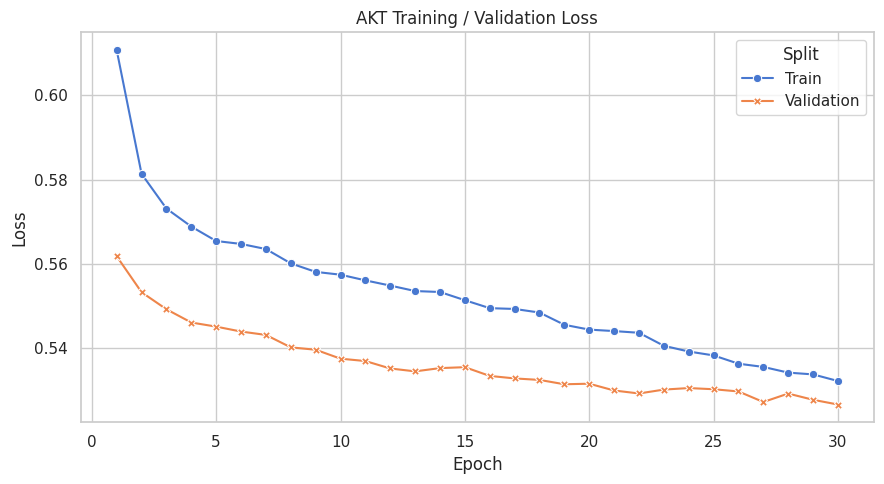

In [63]:
if len(val_losses) == 0:
    print("No loss history available yet. Run training first.")
else:
    epochs_range = list(range(1, len(train_losses) + 1))
    loss_df = pd.DataFrame({
        "Epoch": epochs_range * 2,
        "Loss": train_losses + val_losses,
        "Split": ["Train"] * len(train_losses) + ["Validation"] * len(val_losses),
    })

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(data=loss_df, x="Epoch", y="Loss", hue="Split",
                 style="Split", markers=True, dashes=False, ax=ax)
    ax.set_title("AKT Training / Validation Loss")
    fig.tight_layout()
    plt.show()

In [64]:
model.eval()
all_p, all_y = [], []

with torch.no_grad():
    for question, concept, response, seq_len in test_loader:
        question, concept, response, seq_len = [
            t.to(device) for t in (question, concept, response, seq_len)
        ]

        pred, _, mask = model(question, concept, response, seq_len)

        pred_np = pred.squeeze(-1).detach().cpu().numpy()       # (B, T-1)
        target_np = response[:, 1:].cpu().numpy()               # (B, T-1)
        mask_np = mask.squeeze(-1).cpu().numpy().astype(bool)   # (B, T-1)

        all_p.append(pred_np[mask_np])
        all_y.append(target_np[mask_np])

all_p = np.concatenate(all_p)
all_y = np.concatenate(all_y)

acc = accuracy_score(all_y, (all_p >= 0.5).astype(int))
auc = roc_auc_score(all_y, all_p) if len(np.unique(all_y)) > 1 else float("nan")

print("test accuracy:", acc)
print("test auc:", auc)

test accuracy: 0.7299488054607508
test auc: 0.7540169262030514


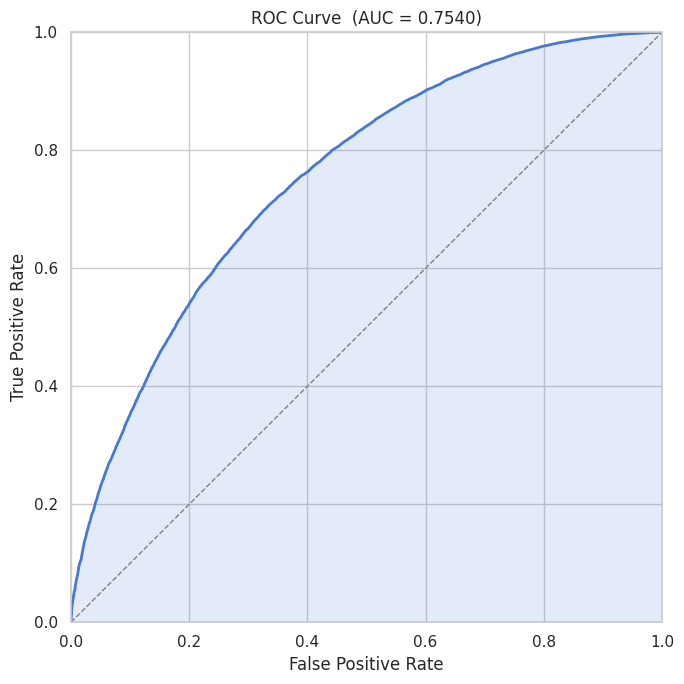

In [65]:
fpr, tpr, thresholds = roc_curve(all_y, all_p)

roc_df = pd.DataFrame({"False Positive Rate": fpr, "True Positive Rate": tpr})

fig, ax = plt.subplots(figsize=(7, 7))
sns.lineplot(data=roc_df, x="False Positive Rate", y="True Positive Rate",
             ax=ax, linewidth=2)
ax.plot([0, 1], [0, 1], ls="--", color="grey", linewidth=1)
ax.fill_between(fpr, tpr, alpha=0.15)
ax.set_title(f"ROC Curve  (AUC = {auc:.4f})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

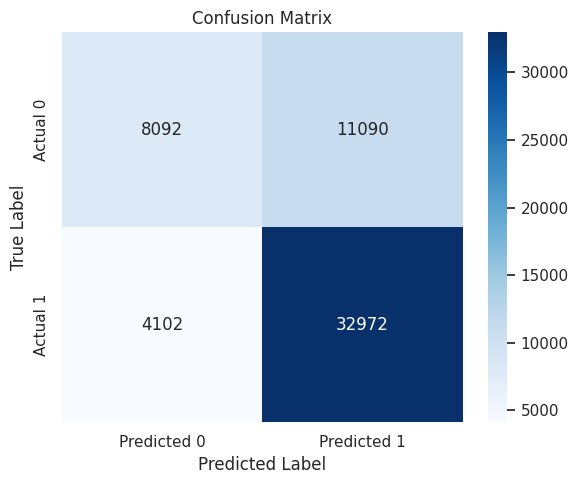

In [66]:
y_pred = (all_p >= 0.5).astype(int)
cm = confusion_matrix(all_y, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"], ax=ax)
ax.set_title("Confusion Matrix")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
fig.tight_layout()
plt.show()